# Q5: PCA and t-SNE from Scratch - BSDS500 Pixel Data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

np.random.seed(42)

BASE = "/home/claude/dataset"
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")
IMAGES_TRAIN = os.path.join(BASE, "images", "train")

### Load a set of images and sample pixels from each

In [2]:
def extract_pixel_features(img_array):
    gray = img_array.mean(axis=2)
    grad_y = np.abs(np.diff(gray, axis=0, prepend=gray[:1, :]))
    grad_x = np.abs(np.diff(gray, axis=1, prepend=gray[:, :1]))
    grad_mag = np.sqrt(grad_x ** 2 + grad_y ** 2)
    feats = np.stack([img_array[:, :, 0], img_array[:, :, 1], img_array[:, :, 2], gray, grad_mag], axis=-1)
    return feats.reshape(-1, 5)

def load_pixel_sample(images_dir, max_images, pixels_per_image, seed=0):
    rng = np.random.RandomState(seed)
    filenames = sorted(f for f in os.listdir(images_dir) if f.lower().endswith(IMAGE_EXTENSIONS))[:max_images]
    X_parts, image_id_parts = [], []
    total_pixels = 0
    for img_idx, fname in enumerate(filenames):
        img = np.array(Image.open(os.path.join(images_dir, fname)).convert("RGB"), dtype=float) / 255.0
        feats_full = extract_pixel_features(img)
        total_pixels += feats_full.shape[0]
        idx = rng.choice(feats_full.shape[0], min(pixels_per_image, feats_full.shape[0]), replace=False)
        X_parts.append(feats_full[idx])
        image_id_parts.append(np.full(len(idx), img_idx))
    X = np.vstack(X_parts)
    image_ids = np.concatenate(image_id_parts)
    return X, image_ids, total_pixels, len(filenames)

feature_names = ["R", "G", "B", "gray", "gradient_magnitude"]
X, image_ids, total_pixels, n_images = load_pixel_sample(IMAGES_TRAIN, max_images=25, pixels_per_image=400)

print("Images used:", n_images)
print("Total pixels available across those images:", total_pixels)
print("Sampled pixel feature matrix shape:", X.shape)
print(pd.DataFrame(X, columns=feature_names).head())

Images used: 25
Total pixels available across those images: 3860025
Sampled pixel feature matrix shape: (10000, 5)
          R         G         B      gray  gradient_magnitude
0  0.317647  0.427451  0.372549  0.372549            0.011765
1  0.235294  0.486275  0.525490  0.415686            0.047222
2  0.192157  0.286275  0.235294  0.237908            0.027451
3  0.462745  0.533333  0.486275  0.494118            0.019608
4  0.258824  0.388235  0.352941  0.333333            0.024802


### Center the data

In [3]:
mean_vector = X.mean(axis=0)
X_centered = X - mean_vector
print("Mean of R channel before centering:", round(X[:, 0].mean(), 3))
print("Mean of R channel after centering:", round(X_centered[:, 0].mean(), 3))

Mean of R channel before centering: 0.434
Mean of R channel after centering: 0.0


### Covariance matrix

In [4]:
cov_matrix = np.cov(X_centered, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (5, 5)


### Eigen decomposition

In [5]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]
print("Eigenvalues:", np.round(eigenvalues, 4))

Eigenvalues: [ 0.1924  0.0141  0.0049  0.0044 -0.    ]


### Project onto top 2 components

In [6]:
top2_vectors = eigenvectors[:, :2]
X_pca = X_centered.dot(top2_vectors)
explained_ratio = eigenvalues[:2] / eigenvalues.sum()
print("X_pca shape:", X_pca.shape)
print("Variance explained by PC1:", round(explained_ratio[0], 3))
print("Variance explained by PC2:", round(explained_ratio[1], 3))

X_pca shape: (10000, 2)
Variance explained by PC1: 0.892
Variance explained by PC2: 0.065


### Subsample further for t-SNE (O(n^2) cost)

In [7]:
tsne_sample_size = 500
tsne_idx = np.random.choice(len(X), tsne_sample_size, replace=False)
X_tsne_input = X[tsne_idx]
image_ids_tsne = image_ids[tsne_idx]
print("t-SNE working on", tsne_sample_size, "pixel samples")

t-SNE working on 500 pixel samples


### High-dimensional pairwise distances

In [8]:
sum_sq = np.sum(X_tsne_input ** 2, axis=1)
dist_matrix = sum_sq[:, None] + sum_sq[None, :] - 2 * X_tsne_input.dot(X_tsne_input.T)

### Convert distances to affinities (perplexity-based Gaussian widths)

In [9]:
perplexity = 30
target_entropy = np.log(perplexity)
n = tsne_sample_size
P = np.zeros((n, n))

for i in range(n):
    d_i = np.delete(dist_matrix[i], i)
    beta_min, beta_max = -np.inf, np.inf
    beta = 1.0
    for _ in range(50):
        logits = -d_i * beta
        logits -= logits.max()
        unnorm_p = np.exp(logits)
        p_i = unnorm_p / unnorm_p.sum()
        entropy = -np.sum(p_i * np.log(p_i + 1e-12))
        diff = entropy - target_entropy
        if abs(diff) < 1e-5:
            break
        if diff > 0:
            beta_min = beta
            beta = beta * 2 if beta_max == np.inf else (beta + beta_max) / 2
        else:
            beta_max = beta
            beta = beta / 2 if beta_min == -np.inf else (beta + beta_min) / 2
    full_p = np.zeros(n)
    full_p[np.arange(n) != i] = p_i
    P[i] = full_p

P = (P + P.T) / (2 * n)
P = np.maximum(P, 1e-12)
P = P * 4
print("P matrix shape:", P.shape)

P matrix shape: (500, 500)


### Gradient descent on 2D positions

In [10]:
Y = np.random.normal(0, 1e-4, size=(n, 2))
velocity = np.zeros_like(Y)
momentum = 0.8
learning_rate = 150
n_iterations = 500

for it in range(n_iterations):
    sum_sq_y = np.sum(Y ** 2, axis=1)
    dist_y = sum_sq_y[:, None] + sum_sq_y[None, :] - 2 * Y.dot(Y.T)
    inv_dist = 1 / (1 + dist_y)
    np.fill_diagonal(inv_dist, 0)
    Q = inv_dist / inv_dist.sum()
    Q = np.maximum(Q, 1e-12)
    diff_matrix = (P - Q) * inv_dist
    grad = np.zeros_like(Y)
    for i in range(n):
        grad[i] = 4 * np.sum(diff_matrix[i][:, None] * (Y[i] - Y), axis=0)
    velocity = momentum * velocity - learning_rate * grad
    Y = Y + velocity
    if it == 100:
        P = P / 4
    if (it + 1) % 100 == 0:
        kl_divergence = np.sum(P * np.log(P / Q))
        print("iteration", it + 1, "/", n_iterations, " KL divergence =", round(kl_divergence, 3))

print("t-SNE finished, Y shape:", Y.shape)

iteration 100 / 500  KL divergence = 10.785


iteration 200 / 500  KL divergence = 0.446


iteration 300 / 500  KL divergence = 0.405


iteration 400 / 500  KL divergence = 0.39


iteration 500 / 500  KL divergence = 0.382
t-SNE finished, Y shape: (500, 2)


### Plot PCA and t-SNE, colored by which image the pixel came from

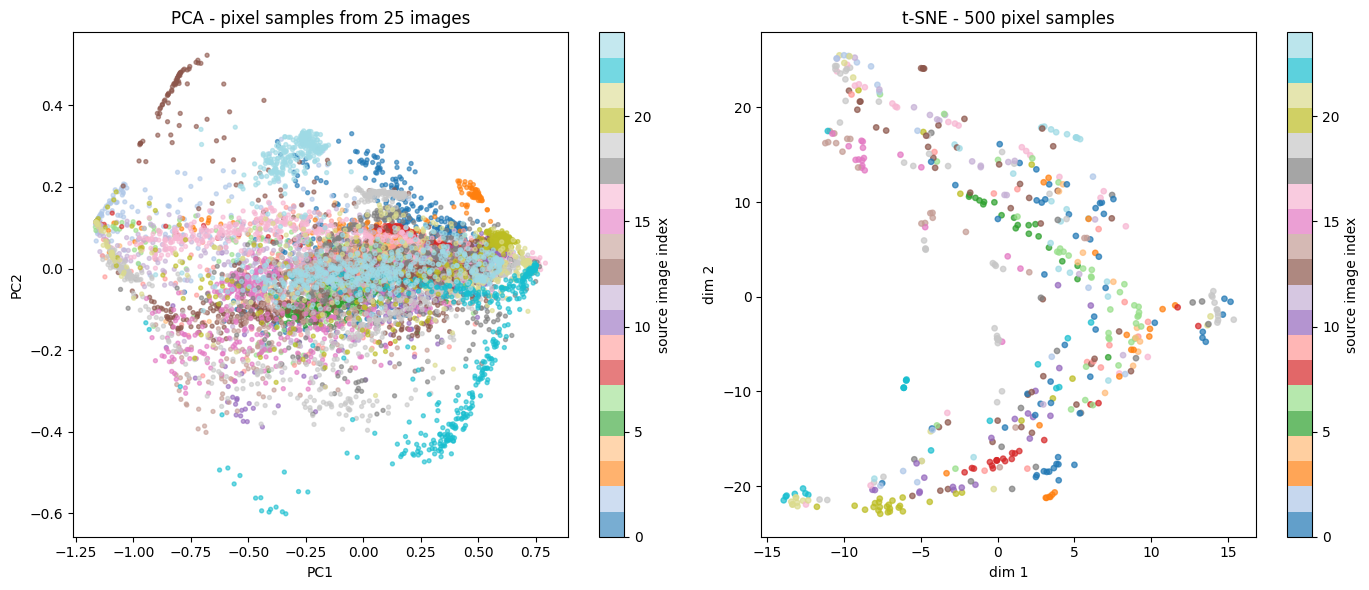

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=image_ids, cmap="tab20", s=8, alpha=0.6)
axes[0].set_title(f"PCA - pixel samples from {n_images} images")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="source image index")

sc2 = axes[1].scatter(Y[:, 0], Y[:, 1], c=image_ids_tsne, cmap="tab20", s=15, alpha=0.7)
axes[1].set_title(f"t-SNE - {tsne_sample_size} pixel samples")
axes[1].set_xlabel("dim 1")
axes[1].set_ylabel("dim 2")
plt.colorbar(sc2, ax=axes[1], label="source image index")

plt.tight_layout()
plt.show()